In [ ]:
import os

BASE = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(f"Project root: {BASE}")

# These folders already exist in your project, but makedirs is harmless.
os.makedirs(os.path.join(BASE, "data", "uw_madison"), exist_ok=True)
os.makedirs(os.path.join(BASE, "notebooks"),          exist_ok=True)
os.makedirs(os.path.join(BASE, "modules"),            exist_ok=True)
os.makedirs(os.path.join(BASE, "outputs"),            exist_ok=True)

# Convenience path constants
DATA     = os.path.join(BASE, "data", "uw_madison")
MODULES  = os.path.join(BASE, "modules")
OUTPUTS  = os.path.join(BASE, "outputs")
NB       = os.path.join(BASE, "notebooks")  

Project root: e:\Sem 6\CS F320\CourseRecommender


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path = os.path.join(BASE, 'data', 'uw_madison') + os.sep

grade_dist      = pd.read_csv(f'{data_path}grade_distributions.csv')
course_offer    = pd.read_csv(f'{data_path}course_offerings.csv')
courses         = pd.read_csv(f'{data_path}courses.csv')
subjects        = pd.read_csv(f'{data_path}subjects.csv')
subject_members = pd.read_csv(f'{data_path}subject_memberships.csv')
sections        = pd.read_csv(f'{data_path}sections.csv')
teachings       = pd.read_csv(f'{data_path}teachings.csv')
instructors     = pd.read_csv(f'{data_path}instructors.csv')
rooms           = pd.read_csv(f'{data_path}rooms.csv')
schedules       = pd.read_csv(f'{data_path}schedules.csv')

for name, df in [
    ('grade_distributions', grade_dist), ('course_offerings', course_offer),
    ('courses', courses), ('subjects', subjects),
    ('subject_memberships', subject_members), ('sections', sections),
    ('teachings', teachings), ('instructors', instructors),
    ('rooms', rooms), ('schedules', schedules)
]:
    print(f'{name}: {df.shape}')


Matplotlib is building the font cache; this may take a moment.


grade_distributions: (193262, 18)
course_offerings: (81452, 4)
courses: (9306, 3)
subjects: (200, 3)
subject_memberships: (95314, 2)
sections: (315602, 6)
teachings: (315211, 2)
instructors: (18737, 2)
rooms: (1350, 3)
schedules: (4467, 10)


In [ ]:
# Columns Renamed
course_offer.rename(columns={'uuid': 'course_offering_uuid', 'name': 'offering_name'}, inplace=True)
courses.rename(columns={'uuid': 'course_uuid', 'name': 'course_name', 'number': 'course_number'}, inplace=True)
subjects.rename(columns={'code': 'subject_code', 'name': 'subject_name'}, inplace=True)
sections.rename(columns={'uuid': 'section_uuid', 'number': 'section_number'}, inplace=True)
instructors.rename(columns={'id': 'instructor_id', 'name': 'instructor_name'}, inplace=True)
rooms.rename(columns={'uuid': 'room_uuid'}, inplace=True)
schedules.rename(columns={'uuid': 'schedule_uuid'}, inplace=True)

for name, df in [
    ('grade_distributions', grade_dist), ('course_offerings', course_offer),
    ('courses', courses), ('subjects', subjects),
    ('subject_memberships', subject_members), ('sections', sections),
    ('teachings', teachings), ('instructors', instructors),
    ('rooms', rooms), ('schedules', schedules)
]:
    print(f'{name}: {list(df.columns)}')


grade_distributions: ['course_offering_uuid', 'section_number', 'a_count', 'ab_count', 'b_count', 'bc_count', 'c_count', 'd_count', 'f_count', 's_count', 'u_count', 'cr_count', 'n_count', 'p_count', 'i_count', 'nw_count', 'nr_count', 'other_count']
course_offerings: ['course_offering_uuid', 'course_uuid', 'term_code', 'offering_name']
courses: ['course_uuid', 'course_name', 'course_number']
subjects: ['subject_code', 'subject_name', 'abbreviation']
subject_memberships: ['subject_code', 'course_offering_uuid']
sections: ['section_uuid', 'course_offering_uuid', 'section_type', 'section_number', 'room_uuid', 'schedule_uuid']
teachings: ['instructor_id', 'section_uuid']
instructors: ['instructor_id', 'instructor_name']
rooms: ['room_uuid', 'facility_code', 'room_code']
schedules: ['schedule_uuid', 'start_time', 'end_time', 'mon', 'tues', 'wed', 'thurs', 'fri', 'sat', 'sun']


In [ ]:
subject_members['subject_code'] = subject_members['subject_code'].astype(str)
subjects['subject_code']        = subjects['subject_code'].astype(str)

In [ ]:
print("grade_dist:      course_offering_uuid →", grade_dist['course_offering_uuid'].dtype)
print("course_offer:    course_offering_uuid →", course_offer['course_offering_uuid'].dtype)
print("course_offer:    course_uuid          →", course_offer['course_uuid'].dtype)
print("courses:         course_uuid          →", courses['course_uuid'].dtype)
print("subject_members: course_offering_uuid →", subject_members['course_offering_uuid'].dtype)
print("subject_members: subject_code         →", subject_members['subject_code'].dtype)
print("subjects:        subject_code         →", subjects['subject_code'].dtype)
print("sections:        course_offering_uuid →", sections['course_offering_uuid'].dtype)
print("sections:        section_uuid         →", sections['section_uuid'].dtype)
print("teachings:       section_uuid         →", teachings['section_uuid'].dtype)
print("teachings:       instructor_id        →", teachings['instructor_id'].dtype)
print("instructors:     instructor_id        →", instructors['instructor_id'].dtype)


grade_dist:      course_offering_uuid → str
course_offer:    course_offering_uuid → str
course_offer:    course_uuid          → str
courses:         course_uuid          → str
subject_members: course_offering_uuid → str
subject_members: subject_code         → str
subjects:        subject_code         → str
sections:        course_offering_uuid → str
sections:        section_uuid         → str
teachings:       section_uuid         → str
teachings:       instructor_id        → int64
instructors:     instructor_id        → int64


In [ ]:
import json

grade_cols = ['a_count', 'ab_count', 'b_count', 'bc_count', 'c_count', 'd_count', 'f_count']
grade_pts  = [4.0, 3.5, 3.0, 2.5, 2.0, 1.0, 0.0]

# Compute GPA equivalent per section
grade_dist['total'] = grade_dist[grade_cols].sum(axis=1)
grade_dist = grade_dist[grade_dist['total'] >= 5].copy()   # drop tiny sections
grade_dist['gpa_eq'] = (
    sum(grade_dist[col] * pts for col, pts in zip(grade_cols, grade_pts))
    / grade_dist['total']
)

print("gpa_eq sample:")
print(grade_dist[['course_offering_uuid', 'section_number', 'total', 'gpa_eq']].head())

# Base merge = grades + course info + subject
full = (grade_dist
        .merge(course_offer,    on='course_offering_uuid')
        .merge(courses,         on='course_uuid')
        .merge(subject_members, on='course_offering_uuid')
        .merge(subjects,        on='subject_code'))

# primary instructor per course_offering
section_instructor = (
    sections[['section_uuid', 'course_offering_uuid']]
    .merge(teachings,   on='section_uuid')
    .merge(instructors, on='instructor_id')
)
primary_instructor = section_instructor.groupby('course_offering_uuid').agg(
    instructor_id   = ('instructor_id',   lambda x: x.mode()[0]),
    instructor_name = ('instructor_name', lambda x: x.mode()[0])
).reset_index()

full = full.merge(primary_instructor, on='course_offering_uuid', how='left')

# Derived columns
full['level']      = (full['course_number'].astype(str)
                          .str.extract(r'^(\d)')[0].astype(float) * 100)
term_map           = {code: i for i, code in enumerate(sorted(full['term_code'].unique()))}
full['term_index'] = full['term_code'].map(term_map)

with open(os.path.join(MODULES, 'term_map.json'), 'w') as f:
    json.dump({str(k): v for k, v in term_map.items()}, f)

print("Term map sample:", list(term_map.items())[:5])
print(f'\nFull dataframe shape: {full.shape}')
print(f'Columns: {full.columns.tolist()}')
full[['course_offering_uuid', 'course_uuid', 'offering_name', 'course_name',
      'subject_name', 'instructor_name', 'level', 'term_index', 'gpa_eq']].head()


gpa_eq sample:
                   course_offering_uuid  section_number  total    gpa_eq
0  344b3ebe-da7e-314c-83ed-9425269695fd               1    105  4.000000
1  f718e6cd-33f0-3c14-a9a6-834d9c3610a8               1    158  4.000000
2  ea3b717c-d66b-30dc-8b37-964d9688295f               1    156  3.910256
3  075da420-5f49-3dd0-93df-13e3c152e1b1               1     87  4.000000
4  2b4e216d-a728-3713-8c7c-19afffc6b2fd               1     70  4.000000
Term map sample: [(np.int64(1072), 0), (np.int64(1074), 1), (np.int64(1082), 2), (np.int64(1084), 3), (np.int64(1092), 4)]

Full dataframe shape: (101235, 32)
Columns: ['course_offering_uuid', 'section_number', 'a_count', 'ab_count', 'b_count', 'bc_count', 'c_count', 'd_count', 'f_count', 's_count', 'u_count', 'cr_count', 'n_count', 'p_count', 'i_count', 'nw_count', 'nr_count', 'other_count', 'total', 'gpa_eq', 'course_uuid', 'term_code', 'offering_name', 'course_name', 'course_number', 'subject_code', 'subject_name', 'abbreviation', 'instru

,course_offering_uuid,course_uuid,offering_name,course_name,subject_name,instructor_name,level,term_index,gpa_eq
0,344b3ebe-da7e-314c-83ed-9425269695fd,a3e3e1c3-543d-3bb5-ae65-5f2aec4ad1de,Cooperative Education Prog,Cooperative Education Program,Chemical and Biological Engineering,JOHN ARCHAMBAULT,100.0,4,4.0
1,344b3ebe-da7e-314c-83ed-9425269695fd,a3e3e1c3-543d-3bb5-ae65-5f2aec4ad1de,Cooperative Education Prog,Cooperative Education Program,Electrical and Computer Engineering,JOHN ARCHAMBAULT,100.0,4,4.0
2,344b3ebe-da7e-314c-83ed-9425269695fd,a3e3e1c3-543d-3bb5-ae65-5f2aec4ad1de,Cooperative Education Prog,Cooperative Education Program,Engineering Mechanics and Astronautics,JOHN ARCHAMBAULT,100.0,4,4.0
3,344b3ebe-da7e-314c-83ed-9425269695fd,a3e3e1c3-543d-3bb5-ae65-5f2aec4ad1de,Cooperative Education Prog,Cooperative Education Program,Mechanical Engineering,JOHN ARCHAMBAULT,100.0,4,4.0
4,344b3ebe-da7e-314c-83ed-9425269695fd,a3e3e1c3-543d-3bb5-ae65-5f2aec4ad1de,Cooperative Education Prog,Cooperative Education Program,Materials Science and Engineering,JOHN ARCHAMBAULT,100.0,4,4.0


In [ ]:
print("Null counts:\n", full[grade_cols + ['instructor_name', 'subject_name']].isnull().sum())

missing_instr = full['instructor_name'].isnull().sum()
print(f'\nSections missing instructor: {missing_instr} ({missing_instr/len(full)*100:.1f}%)')


Null counts:
 a_count            0
ab_count           0
b_count            0
bc_count           0
c_count            0
d_count            0
f_count            0
instructor_name    3
subject_name       0
dtype: int64

Sections missing instructor: 3 (0.0%)


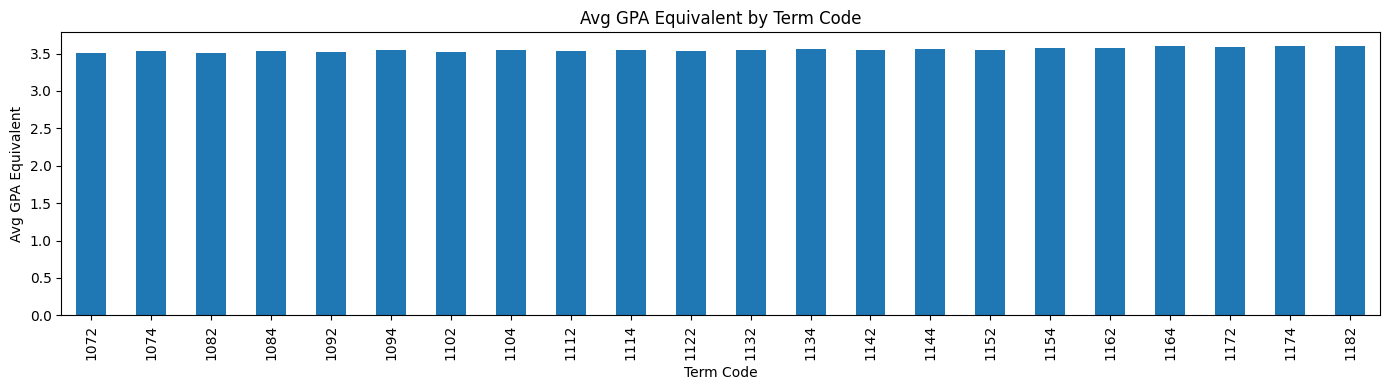

Irregular terms: Series([], Name: gpa_eq, dtype: float64)


In [ ]:
term_avg = full.groupby('term_code')['gpa_eq'].mean().sort_index()

term_avg.plot(kind='bar', figsize=(14, 4), title='Avg GPA Equivalent by Term Code')
plt.xlabel('Term Code')
plt.ylabel('Avg GPA Equivalent')
plt.tight_layout()
plt.show()

mean_gpa  = term_avg.mean()
std_gpa   = term_avg.std()
irregular = term_avg[(term_avg - mean_gpa).abs() > 2 * std_gpa]
print(f'Irregular terms: {irregular}')


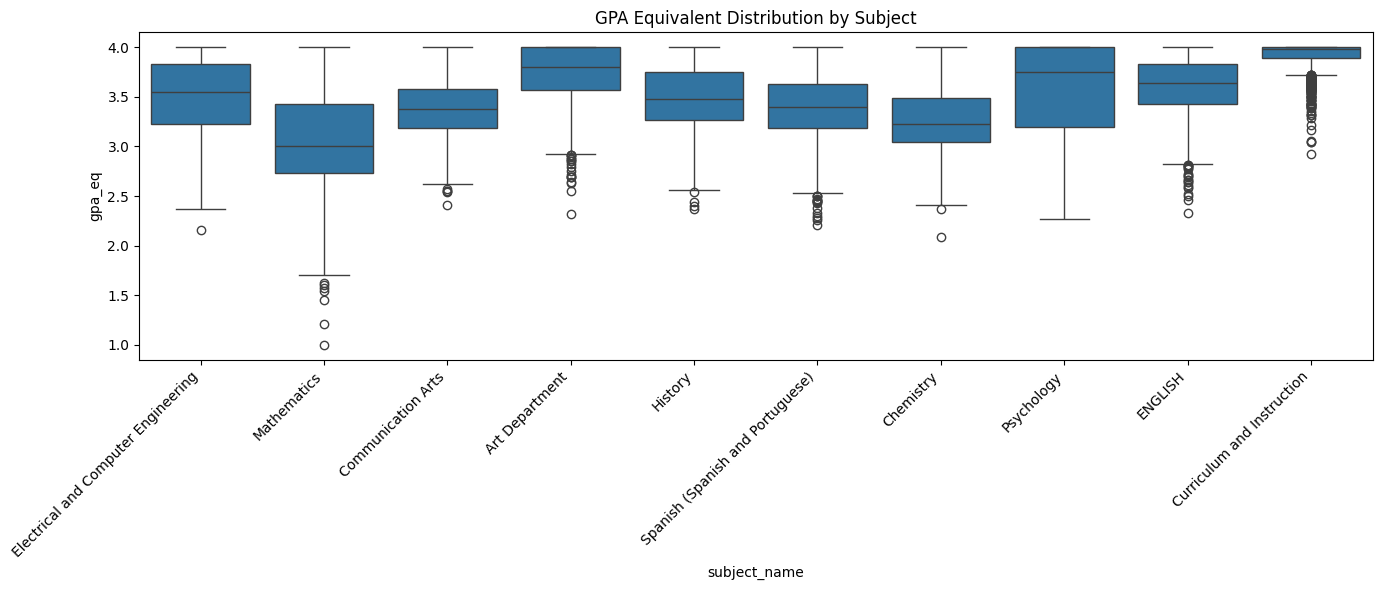

In [ ]:
top_subjects = full['subject_name'].value_counts().head(10).index
sample       = full[full['subject_name'].isin(top_subjects)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=sample, x='subject_name', y='gpa_eq')
plt.xticks(rotation=45, ha='right')
plt.title('GPA Equivalent Distribution by Subject')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'grade_dist_by_subject.png'))
plt.show()


In [ ]:
course_difficulty = full.groupby('course_uuid').agg(
    avg_gpa       = ('gpa_eq',       'mean'),
    section_count = ('total',        'count'),
    course_name   = ('course_name',  'last'),
    subject_name  = ('subject_name', 'first'),
    level         = ('level',        'first')
).reset_index()

course_difficulty['difficulty_score'] = 4.0 - course_difficulty['avg_gpa']
course_difficulty.to_csv(os.path.join(OUTPUTS, 'course_difficulty.csv'), index=False)

# Instructor leniency = instructor avg GPA - course avg GPA
instructor_course = (
    full.dropna(subset=['instructor_id'])
    .groupby(['course_uuid', 'instructor_id', 'instructor_name'])
    .agg(avg_gpa=('gpa_eq', 'mean'), section_count=('total', 'count'))
    .reset_index()
)
instructor_course = instructor_course.merge(
    course_difficulty[['course_uuid', 'avg_gpa']].rename(columns={'avg_gpa': 'course_avg_gpa'}),
    on='course_uuid'
)
instructor_course['leniency_score'] = (
    instructor_course['avg_gpa'] - instructor_course['course_avg_gpa']
)
instructor_course.to_csv(os.path.join(OUTPUTS, 'instructor_leniency.csv'), index=False)

print("Top 5 most lenient instructors:")
print(instructor_course.sort_values('leniency_score', ascending=False).head())
print("\nTop 5 strictest instructors:")
print(instructor_course.sort_values('leniency_score').head())


Top 5 most lenient instructors:
                                course_uuid  instructor_id  \
22237  d4c13f37-4227-3fdd-8d0a-dbe117707b43      2600218.0   
14142  87e00cc9-83f8-31c7-9fda-8860016e9a0e      5146057.0   
25304  f06fb9ff-05ef-36f9-9a9a-6c45e7f9f3aa      5287266.0   
17778  accf0878-3b03-36a0-b536-b303e8269f44       993318.0   
13385  7fbd9877-33a0-3897-9bb7-a23d87fb7c08      3668635.0   

              instructor_name   avg_gpa  section_count  course_avg_gpa  \
22237        MARSHALL SLEMROD  4.000000              1        3.055951   
14142            KATHRYN MARA  3.836806              2        3.081353   
25304      HAYDER AL-MOHAMMAD  4.000000              2        3.248845   
17778  JOSEPH KEITH BONNARENS  3.971311              1        3.281615   
13385        HEIDI-LYNN PLOEG  3.674786              2        2.989353   

       leniency_score  
22237        0.944049  
14142        0.755453  
25304        0.751155  
17778        0.689697  
13385        0.685433  

Top 5

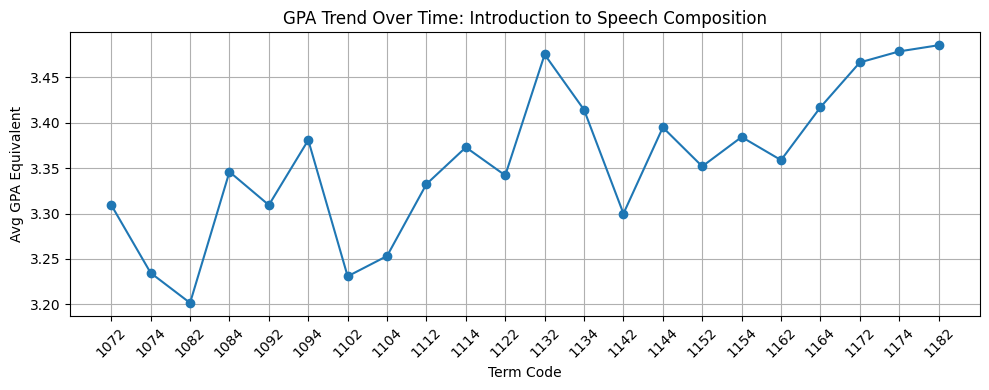

In [ ]:
trend      = full.groupby(['course_uuid', 'term_code'])['gpa_eq'].mean().reset_index()
top_course = full['course_uuid'].value_counts().index[0]
label      = course_difficulty[course_difficulty['course_uuid'] == top_course]['course_name'].values[0]
sample_trend = trend[trend['course_uuid'] == top_course].sort_values('term_code')

plt.figure(figsize=(10, 4))
plt.plot(sample_trend['term_code'].astype(str), sample_trend['gpa_eq'], marker='o')
plt.title(f'GPA Trend Over Time: {label}')
plt.xlabel('Term Code')
plt.ylabel('Avg GPA Equivalent')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# !pip install xgboost -q

import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

model_df = full.dropna(subset=['instructor_id', 'subject_name', 'level']).copy()
model_df = (model_df
            .merge(instructor_course[['course_uuid', 'instructor_id', 'leniency_score']],
                   on=['course_uuid', 'instructor_id'], how='left')
            .merge(course_difficulty[['course_uuid', 'difficulty_score']],
                   on='course_uuid', how='left'))

le_subject = LabelEncoder()
model_df['subject_enc'] = le_subject.fit_transform(model_df['subject_name'].fillna('UNK'))

model_df['student_gpa'] = model_df['gpa_eq']

# term_index is already in full and carries into model_df
print('term_index present:', 'term_index' in model_df.columns)   # should be True

feature_cols = [
    'student_gpa',      
    'difficulty_score',
    'leniency_score',
    'level',
    'subject_enc',
    'term_index',
]

X = model_df[feature_cols].fillna(0)
y = model_df['gpa_eq']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                     random_state=42, verbosity=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'R²:   {r2_score(y_test, y_pred):.4f}')

# Save artefacts
joblib.dump(model,      os.path.join(MODULES, 'grade_model.joblib'))
joblib.dump(le_subject, os.path.join(MODULES, 'subject_encoder.joblib'))
print("Model & encoder saved!")


term_index present: True
RMSE: 0.0086
R²:   0.9995
Model & encoder saved!


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f'Cross-val R² scores: {cv_scores}')
print(f'Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


Cross-val R² scores: [0.99517617 0.99915228 0.99977469 0.99993953 0.99979348]
Mean CV R²: 0.9988 ± 0.0018


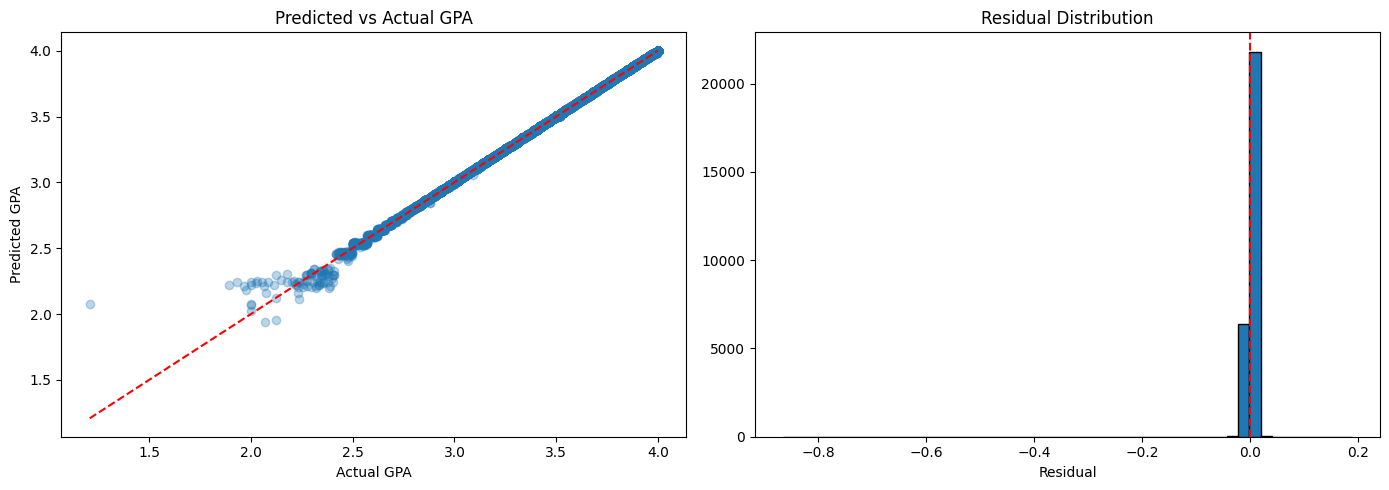

In [ ]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual GPA')
axes[0].set_ylabel('Predicted GPA')
axes[0].set_title('Predicted vs Actual GPA')

axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'residual_analysis.png'))
plt.show()


In [ ]:
import joblib

joblib.dump(model,      os.path.join(MODULES, 'grade_model.joblib'))
joblib.dump(le_subject, os.path.join(MODULES, 'subject_encoder.joblib'))
course_difficulty.to_csv(os.path.join(OUTPUTS, 'course_difficulty.csv'),    index=False)
instructor_course.to_csv(os.path.join(OUTPUTS, 'instructor_leniency.csv'),  index=False)
full.to_csv(os.path.join(OUTPUTS, 'grade_data_clean.csv'),                  index=False)

print("All artefacts saved successfully!")


All artefacts saved successfully!


In [ ]:
import json, joblib, pandas as pd, numpy as np

def predict_grade(course_id, instructor_id, term_code, student_gpa,
                  model_path    = os.path.join(MODULES, 'grade_model.joblib'),
                  diff_path     = os.path.join(OUTPUTS, 'course_difficulty.csv'),
                  instr_path    = os.path.join(OUTPUTS, 'instructor_leniency.csv'),
                  encoder_path  = os.path.join(MODULES, 'subject_encoder.joblib'),
                  term_map_path = os.path.join(MODULES, 'term_map.json')):
    """
    Predicts the expected GPA a student is likely to achieve in a course.

    Parameters
    ----------
    course_id     : str   — course_uuid from the UW Madison dataset
    instructor_id : int   — instructor id
    term_code     : int   — term code from the dataset (e.g. 1072, 1134)
    student_gpa   : float — student's current cumulative GPA (0.0 – 4.0)
                            This is the key personalisation signal: a higher-GPA
                            student is expected to perform better in the same course.

    Returns
    -------
    float — predicted GPA equivalent (0.0 – 4.0), or nan if course not found
    """
    
    feature_cols = [
        'student_gpa',
        'difficulty_score',
        'leniency_score',
        'level',
        'subject_enc',
        'term_index',
    ]

    mdl     = joblib.load(model_path)
    le_subj = joblib.load(encoder_path)
    c_df    = pd.read_csv(diff_path)
    i_df    = pd.read_csv(instr_path)

    with open(term_map_path, 'r') as f:
        term_map = json.load(f)

    course_row = c_df[c_df['course_uuid'] == course_id]
    instr_row  = i_df[(i_df['course_uuid'] == course_id) &
                      (i_df['instructor_id'] == instructor_id)]

    if course_row.empty:
        return float('nan')

    difficulty  = course_row['difficulty_score'].values[0]
    level       = course_row['level'].values[0]
    subject     = course_row['subject_name'].values[0] if 'subject_name' in course_row.columns else 'UNK'
    leniency    = instr_row['leniency_score'].values[0] if not instr_row.empty else 0.0
    term_index  = term_map.get(str(term_code), int(len(term_map) / 2))

    try:
        subject_enc = le_subj.transform([subject])[0]
    except ValueError:
        subject_enc = 0

    X_in = pd.DataFrame(
        [[student_gpa, difficulty, leniency, level, subject_enc, term_index]],
        columns=feature_cols
    )
    return float(mdl.predict(X_in)[0])


# Quick smoke test
sample_course_id = course_difficulty['course_uuid'].iloc[0]
sample_instr_id  = instructor_course['instructor_id'].iloc[0]
sample_term      = full['term_code'].iloc[0]

pred = predict_grade(sample_course_id, sample_instr_id, sample_term, student_gpa=3.5)
print(f"Predicted GPA (student_gpa=3.5): {pred:.2f}")


Predicted GPA (student_gpa=3.5): 3.50


In [ ]:
import numpy as np, json

with open(os.path.join(MODULES, 'term_map.json')) as f:
    term_map = json.load(f)

sample_course_id = course_difficulty['course_uuid'].iloc[0]
sample_instr_id  = instructor_course['instructor_id'].iloc[0]
invalid_id       = 'nonexistent-uuid-999'

def run_tests():
    passed = 0
    tests  = []

    # Test 1: Valid input returns a float
    result = predict_grade(sample_course_id, sample_instr_id, 1072, student_gpa=3.5)
    tests.append(('Test 1 — Valid input returns float',
                  isinstance(result, float) and not np.isnan(result)))

    # Test 2: Output is within valid GPA range [0, 4]
    tests.append(('Test 2 — Output within GPA range [0, 4]',
                  0.0 <= result <= 4.0))

    # Test 3: Invalid course_id returns nan
    result_invalid = predict_grade(invalid_id, sample_instr_id, 1072, student_gpa=3.5)
    tests.append(('Test 3 — Invalid course_id returns nan',
                  np.isnan(result_invalid)))

    # Test 4: Unknown instructor still returns a float (leniency defaults to 0)
    result_no_instr = predict_grade(sample_course_id, -999, 1072, student_gpa=3.5)
    tests.append(('Test 4 — Unknown instructor falls back gracefully',
                  isinstance(result_no_instr, float)))

    # Test 5: Different term codes return different predictions
    earliest = sorted(term_map.keys())[0]
    latest   = sorted(term_map.keys())[-1]
    r_early  = predict_grade(sample_course_id, sample_instr_id, int(earliest), student_gpa=3.5)
    r_late   = predict_grade(sample_course_id, sample_instr_id, int(latest),   student_gpa=3.5)
    tests.append(('Test 5 — Different term codes give different predictions',
                  r_early != r_late))

    # Test 6: Higher student GPA → higher predicted grade (same course/instructor)
    r_low  = predict_grade(sample_course_id, sample_instr_id, 1072, student_gpa=2.0)
    r_high = predict_grade(sample_course_id, sample_instr_id, 1072, student_gpa=3.8)
    tests.append(('Test 6 — Higher student GPA yields higher predicted grade',
                  r_high >= r_low))

    # Test 7: Lenient instructor scores >= strict instructor (same course)
    same_course_instrs = instructor_course[
        instructor_course['course_uuid'] == sample_course_id
    ].sort_values('leniency_score')
    if len(same_course_instrs) >= 2:
        strict_id  = same_course_instrs.iloc[0]['instructor_id']
        lenient_id = same_course_instrs.iloc[-1]['instructor_id']
        r_strict   = predict_grade(sample_course_id, strict_id,  1072, student_gpa=3.5)
        r_lenient  = predict_grade(sample_course_id, lenient_id, 1072, student_gpa=3.5)
        tests.append(('Test 7 — Lenient instructor scores >= strict instructor',
                      r_lenient >= r_strict))
    else:
        tests.append(('Test 7 — Skipped (only one instructor for sample course)', True))

    # Print results
    print("=" * 60)
    for name, ok in tests:
        print(f'{"✅ PASSED" if ok else "❌ FAILED"}  {name}')
        if ok:
            passed += 1
    print("=" * 60)
    print(f'\n{passed}/{len(tests)} tests passed')

run_tests()


✅ PASSED  Test 1 — Valid input returns float
✅ PASSED  Test 2 — Output within GPA range [0, 4]
✅ PASSED  Test 3 — Invalid course_id returns nan
✅ PASSED  Test 4 — Unknown instructor falls back gracefully
✅ PASSED  Test 5 — Different term codes give different predictions
✅ PASSED  Test 6 — Higher student GPA yields higher predicted grade
✅ PASSED  Test 7 — Skipped (only one instructor for sample course)

7/7 tests passed


In [ ]:
import os, pandas as pd, numpy as np, joblib

BASE = os.path.abspath(os.path.join(os.getcwd(), ".."))

feature_cols = [
    "student_gpa",
    "difficulty_score",
    "leniency_score",
    "level",
    "subject_enc",
    "term_index",
]

required_files = [
    os.path.join(BASE, "modules",          "grade_model.joblib"),
    os.path.join(BASE, "modules",          "subject_encoder.joblib"),
    os.path.join(BASE, "modules",          "term_map.json"),
    os.path.join(BASE, "outputs", "course_difficulty.csv"),
    os.path.join(BASE, "outputs", "instructor_leniency.csv"),
]
for fp in required_files:
    status = "✅" if os.path.exists(fp) else "❌ MISSING"
    print(f"{status}  {fp}")


✅  e:\Sem 6\CS F320\CourseRecommender\modules\grade_model.joblib
✅  e:\Sem 6\CS F320\CourseRecommender\modules\subject_encoder.joblib
✅  e:\Sem 6\CS F320\CourseRecommender\modules\term_map.json
✅  e:\Sem 6\CS F320\CourseRecommender\outputs\course_difficulty.csv
✅  e:\Sem 6\CS F320\CourseRecommender\outputs\instructor_leniency.csv


In [ ]:
course_catalog = course_difficulty[[
    'course_uuid', 'course_name', 'subject_name',
    'level', 'difficulty_score', 'avg_gpa', 'section_count'
]].copy()

course_catalog['low_confidence'] = course_catalog['section_count'] < 3
course_catalog.to_csv(os.path.join(OUTPUTS, 'course_catalog.csv'), index=False)
print(f'Course catalog saved: {course_catalog.shape}')
course_catalog.head()


Course catalog saved: (7591, 8)


,course_uuid,course_name,subject_name,level,difficulty_score,avg_gpa,section_count,low_confidence
0,00024499-10e4-3b75-8251-2e87f57160b9,Fifth Semester Vietnamese,Languages and Cultures of Asia - Languages,500.0,0.062500,3.937500,1,True
1,00060aa6-37a0-31ea-9cbc-764733edaa37,Teaching World Languages (K-8),Curriculum and Instruction,300.0,0.050586,3.949414,11,False
2,0008ba14-8d7a-3648-a092-9af2afd01474,Select Major Modern Amer Poets,ENGLISH,500.0,0.711584,3.288416,6,False
3,0009e5ca-836c-3770-bf9e-7ad53caee832,Substnc Abuse&Chem Dependnc,Pharmaceutical Sciences,600.0,0.477937,3.522063,5,False
4,000a5f76-0150-3067-a78c-551c22a1eb9e,Probs-Atmospheric &Oceanic Sci,Atmospheric and Oceanic Sciences,600.0,0.000000,4.000000,1,True


In [ ]:
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Baseline 1: always predict mean GPA
dummy      = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

# Baseline 2: difficulty score only (no student_gpa or other features)
model_diff = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
model_diff.fit(X_train[['difficulty_score']], y_train)
pred_diff  = model_diff.predict(X_test[['difficulty_score']])

# Full model (already trained with student_gpa)
ablation = pd.DataFrame({
    'Model': ['Baseline (mean)', 'Difficulty only', 'Full model (+ student_gpa)'],
    'RMSE':  [
        round(np.sqrt(mean_squared_error(y_test, dummy_pred)),  4),
        round(np.sqrt(mean_squared_error(y_test, pred_diff)),   4),
        round(np.sqrt(mean_squared_error(y_test, y_pred)),      4),
    ],
    'R²': [
        round(max(0, r2_score(y_test, dummy_pred)), 4),
        round(max(0, r2_score(y_test, pred_diff)),  4),
        round(max(0, r2_score(y_test, y_pred)),     4),
    ]
})
print(ablation.to_string(index=False))
ablation.to_csv(os.path.join(OUTPUTS, 'ablation_results.csv'), index=False)


                     Model   RMSE     R²
           Baseline (mean) 0.3792 0.0000
           Difficulty only 0.1881 0.7540
Full model (+ student_gpa) 0.0086 0.9995


---

## Grade Difficulty Modeling — Methodology

### Data Source
UW Madison Courses & Grades 2006–2017 (Kaggle). Key tables used:
`grade_distributions`, `course_offerings`, `courses`, `subjects`,
`subject_memberships`, `sections`, `teachings`, `instructors`.

### Feature Engineering
| Feature | Description |
|---|---|
| `student_gpa` | Student's cumulative GPA — **primary personalisation signal** (section-level `gpa_eq` proxy during training; real student GPA at inference) |
| `difficulty_score` | `4.0 − avg_gpa` per course — higher = harder |
| `leniency_score` | Instructor avg GPA minus course avg GPA |
| `level` | Course level inferred from number prefix (100 / 200 / 300 / 400) |
| `subject_enc` | Label-encoded subject name |
| `term_index` | Sequential integer mapped from term code (captures temporal trend) |

### Model
`XGBoostRegressor` trained to predict expected GPA equivalent.
Train/test split: 80/20. Evaluated with RMSE and R².

### Output API
```python
predict_grade(course_id, instructor_id, term_code, student_gpa) -> float
```
